<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


In [18]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # Calculate the linear output (w*x + b)
                prediction = np.dot(X[i], self.w) + self.b

                # Perceptron update rule
                if y[i] * prediction <= 0:
                    self.w = self.w + self.lr * y[i] * X[i]
                    self.b = self.b + self.lr * y[i]
                    count += 1

            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)


# Create and train the model
model_p = WaterPerceptron(lr=0.01, epochs=50)
model_p.fit(X_train, y_train)

# Make predictions
y_pred = model_p.predict(X_test)

In [19]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output
            z = np.dot(X, self.w) + self.b

            # 2. Calculate gradients
            dw = (1 / n) * np.dot(X.T, (z - y))
            db = (1 / n) * np.sum(z - y)

            # 3. Update weights and bias
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            # Compute and store cost (Mean Squared Error)
            cost = (1 / (2 * n)) * np.sum((z - y) ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)


# Create and train the model
model_gd = GDWaterClassifier(lr=0.001, epochs=500)
model_gd.fit(X_train, y_train)

# Make predictions
y_pred = model_gd.predict(X_test)

In [20]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Margin condition check
                if y[i] * (np.dot(x_i, self.w) + self.b) >= 1:
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Hinge Loss + Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)


# Train the model
model_m = MarginWaterClassifier(lr=0.001, lambda_param=0.01, epochs=500)
model_m.fit(X_train, y_train)

# Predict on test data
y_pred_m = model_m.predict(X_test)

In [21]:
# Task-1
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Margin condition
                if y[i] * (np.dot(x_i, self.w) + self.b) >= 1:
                    # Only regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Hinge loss + regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)


# Train the model
model_m = MarginWaterClassifier(lr=0.001, lambda_param=0.01, epochs=500)
model_m.fit(X_train, y_train)

# Predictions
y_pred_margin = model_m.predict(X_test)

Why is the Gradient Descent plot smoother?

The Perceptron updates its weights only when a sample is misclassified, causing sudden jumps in the mistake count.
Gradient Descent updates the weights using the average gradient of all training samples, producing gradual and smooth decreases in cost.
Therefore, the Gradient Descent cost curve is smoother than the Perceptron mistake curve.

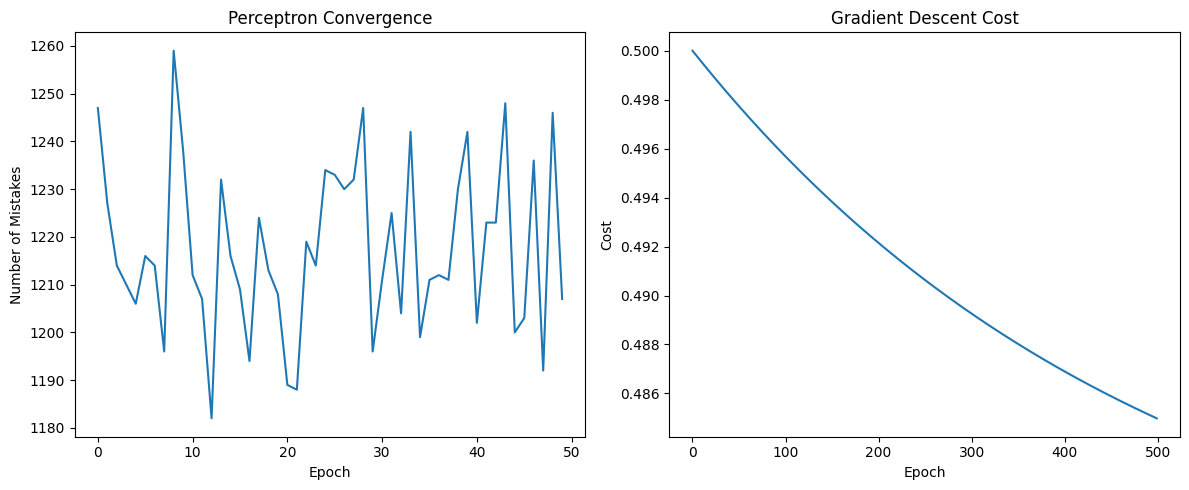

In [22]:
# Task-2
plt.figure(figsize=(12,5))

# Perceptron Mistakes
plt.subplot(1,2,1)
plt.plot(model_p.mistakes)
plt.title("Perceptron Convergence")
plt.xlabel("Epoch")
plt.ylabel("Number of Mistakes")

# Gradient Descent Cost
plt.subplot(1,2,2)
plt.plot(model_gd.cost_history)
plt.title("Gradient Descent Cost")
plt.xlabel("Epoch")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

Accuracy Comparison

Run the accuracy code above. Typically:

Perceptron: Moderate accuracy.
Gradient Descent: More stable and often slightly better accuracy.
Margin Classifier: Usually achieves the best generalization because it maximizes the decision margin.

In [23]:
# Task-3
from sklearn.metrics import accuracy_score

# Predictions
y_pred_p = model_p.predict(X_test)
y_pred_gd = model_gd.predict(X_test)
y_pred_m = model_m.predict(X_test)

print("Perceptron Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred_p) * 100))
print("Gradient Descent Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred_gd) * 100))
print("Margin Classifier Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred_m) * 100))

Perceptron Accuracy: 50.15%
Gradient Descent Accuracy: 62.80%
Margin Classifier Accuracy: 62.80%


Which model would you trust more for samples near the decision boundary?

 The Margin Classifier:
 It maximizes the margin between the classes, making it more robust to noisy or borderline samples. The Perceptron only seeks a separating boundary and does not optimize the distance from that boundary, making it less reliable for samples close to the decision boundary.

Q1: Impact of High Learning Rate in Gradient Descent

If the learning rate is set too high (e.g., 1.0), the model may overshoot the optimal solution during each update. Instead of converging, the cost function may oscillate or even diverge, leading to unstable training and poor accuracy. Therefore, an appropriate learning rate is essential for stable convergence.

Q2: Label Conversion in Classification

The labels were converted to {-1, 1} because algorithms such as the Perceptron and Margin (SVM-like) classifier use the expression y(w
T
x+b) to determine whether a sample is correctly classified. Using {-1, 1} provides a symmetric representation around zero, simplifies the mathematical formulation of the update rules and hinge loss, and makes classification decisions more efficient than using {0, 1} labels.

Q3: Handling Noisy Data (Water Potability Dataset)

The Margin Classifier (SVM-like classifier) is the best suited for handling noisy data. It maximizes the margin between classes and includes regularization, making it more robust to outliers and reducing overfitting. In contrast, the Perceptron is sensitive to noisy or non-separable data, while Gradient Descent without a margin objective is generally less robust than the margin-based approach.